## Final RUL Model Evaluation on C-MAPSS FD001 Test Set

This notebook evaluates the trained RUL model on the official FD001 test dataset, which contains previously unseen engine trajectories.

In [1]:
import pandas as pd
import numpy as np

columns = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

test = pd.read_csv(
    "CMAPSSData/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [2]:
print("Number of test engines:", test["engine_id"].nunique())
print("Test data shape:", test.shape)
print("Last cycle of each test engine:")
print(test.groupby("engine_id")["cycle"].max().head())

Number of test engines: 100
Test data shape: (13096, 26)
Last cycle of each test engine:
engine_id
1     31
2     49
3    126
4    106
5     98
Name: cycle, dtype: int64


In [3]:
rul_test = pd.read_csv(
    "CMAPSSData/RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

rul_test.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [4]:
print("RUL file shape:", rul_test.shape)
print("Number of test engines:", len(rul_test))

RUL file shape: (100, 1)
Number of test engines: 100


In [5]:
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

In [6]:
test_clean = test.drop(columns=constant_sensors).copy()

print("Test clean shape:", test_clean.shape)

Test clean shape: (13096, 20)


In [7]:
feature_sensors = [
    col for col in test_clean.columns
    if col.startswith("sensor_")
]

print("Number of feature sensors:", len(feature_sensors))
print(feature_sensors)

Number of feature sensors: 15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [8]:
test_features = test_clean.copy()

for sensor in feature_sensors:

    # Rolling mean
    test_features[f"{sensor}_rolling_mean"] = (
        test_features.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
    )

    # Rolling standard deviation
    test_features[f"{sensor}_rolling_std"] = (
        test_features.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        )
    )

    # Change from previous cycle
    test_features[f"{sensor}_delta"] = (
        test_features.groupby("engine_id")[sensor].diff()
    )

print("Test feature data shape:", test_features.shape)

Test feature data shape: (13096, 65)


In [9]:
X_test = test_features.drop(columns=["engine_id"]).copy()

print("X_test shape:", X_test.shape)

X_test shape: (13096, 64)


In [10]:
print("Total missing values:", X_test.isnull().sum().sum())

Total missing values: 3000


In [11]:
X_test.isnull().sum().sort_values(ascending=False).head(10)

sensor_3_delta           100
sensor_4_rolling_std     100
sensor_4_delta           100
sensor_6_rolling_std     100
sensor_6_delta           100
sensor_2_rolling_std     100
sensor_3_rolling_std     100
sensor_2_delta           100
sensor_11_rolling_std    100
sensor_11_delta          100
dtype: int64

In [12]:
print("rf_reg exists:", "rf_reg" in globals())
print("X_val_imputed exists:", "X_val_imputed" in globals())

rf_reg exists: False
X_val_imputed exists: False


In [13]:
import os

print("Files in current folder:")
print(os.listdir())

print("\nFiles in models folder:")
if os.path.exists("models"):
    print(os.listdir("models"))
else:
    print("models folder not found")

Files in current folder:
[' 01_data_loading_and_initial_eda.ipynb', ' 02_sensor_degradation_analysis.ipynb', ' 03_rul_modeling_and_comparison.ipynb', ' 04_failure_soon_classification.ipynb', ' 05_random_forest_classification.ipynb', ' 06_model_comparison.ipynb', ' 07_svm_classification.ipynb', ' 08_classification_model_comparison.ipynb', ' 09_rul_regression.ipynb', ' 10_shap_explainability.ipynb', ' 11_model_monitoring_and_drift.ipynb', ' 12_final_test_evaluation.ipynb', '.ipynb_checkpoints', 'CMAPSSData', 'CMAPSSData.zip', 'rf_rul_model.pkl', 'rul_imputer.pkl', 'Untitled.ipynb', 'Untitled1.ipynb', 'X_val_imputed.csv']

Files in models folder:
models folder not found


In [14]:
import joblib

rf_reg = joblib.load("rf_rul_model.pkl")

print("Random Forest model loaded successfully.")
print(type(rf_reg))

Random Forest model loaded successfully.
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [15]:
print("Number of features expected by model:", rf_reg.n_features_in_)

Number of features expected by model: 64


In [16]:
import joblib

imputer = joblib.load("rul_imputer.pkl")

print("Imputer loaded successfully.")

Imputer loaded successfully.


In [17]:
X_test_imputed = imputer.transform(X_test)

print("X_test imputed shape:", X_test_imputed.shape)

X_test imputed shape: (13096, 64)


In [18]:
import numpy as np

print("Missing values after imputation:", np.isnan(X_test_imputed).sum())

Missing values after imputation: 0


In [19]:
# Generate RUL predictions
y_test_pred = rf_reg.predict(X_test_imputed)

print("Number of predictions:", len(y_test_pred))
print("First 10 predicted RUL values:")
print(y_test_pred[:10])

Number of predictions: 13096
First 10 predicted RUL values:
[194.175 217.34  217.535 196.48  194.855 202.955 204.815 222.25  220.705
 229.39 ]


In [20]:
# Get the last observed row of each test engine

last_test_rows = (
    test_features
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .copy()
)

print("Number of final test rows:", len(last_test_rows))
print(last_test_rows[["engine_id", "cycle"]].head())

Number of final test rows: 100
     engine_id  cycle
30           1     31
79           2     49
205          3    126
311          4    106
409          5     98


In [21]:
# Add original row position

test_features_indexed = test_features.copy()
test_features_indexed["row_index"] = range(len(test_features_indexed))

last_test_rows = (
    test_features_indexed
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .sort_values("engine_id")
)

print("Number of final test rows:", len(last_test_rows))
print(last_test_rows[["engine_id", "cycle", "row_index"]].head())

Number of final test rows: 100
     engine_id  cycle  row_index
30           1     31         30
79           2     49         79
205          3    126        205
311          4    106        311
409          5     98        409


In [22]:
final_predictions = y_test_pred[
    last_test_rows["row_index"].values
]

print("Number of final RUL predictions:", len(final_predictions))
print("First 10 final predictions:")
print(final_predictions[:10])

Number of final RUL predictions: 100
First 10 final predictions:
[199.545 160.365  48.72   78.75  115.785 102.095 114.415  63.97  142.285
 126.335]


In [23]:
evaluation = pd.DataFrame({
    "engine_id": last_test_rows["engine_id"].values,
    "actual_RUL": rul_test["RUL"].values,
    "predicted_RUL": final_predictions
})

evaluation.head(10)

,engine_id,actual_RUL,predicted_RUL
0,1,112,199.545
1,2,98,160.365
2,3,69,48.720
3,4,82,78.750
4,5,91,115.785
5,6,93,102.095
6,7,91,114.415
7,8,95,63.970
8,9,111,142.285
9,10,96,126.335


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    evaluation["actual_RUL"],
    evaluation["predicted_RUL"]
)

rmse = np.sqrt(
    mean_squared_error(
        evaluation["actual_RUL"],
        evaluation["predicted_RUL"]
    )
)

r2 = r2_score(
    evaluation["actual_RUL"],
    evaluation["predicted_RUL"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 21.5198
RMSE: 30.20355141369968
R²  : 0.4717293546658067


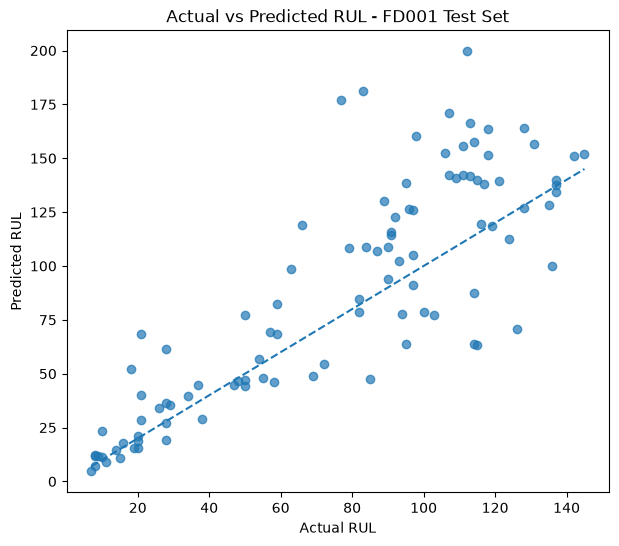

In [29]:
# Prediction Vs Actual visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    evaluation["actual_RUL"],
    evaluation["predicted_RUL"],
    alpha=0.7
)

plt.plot(
    [evaluation["actual_RUL"].min(), evaluation["actual_RUL"].max()],
    [evaluation["actual_RUL"].min(), evaluation["actual_RUL"].max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL - FD001 Test Set")

plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    evaluation["actual_RUL"],
    evaluation["predicted_RUL"]
)

rmse = np.sqrt(mean_squared_error(
    evaluation["actual_RUL"],
    evaluation["predicted_RUL"]
))

r2 = r2_score(
    evaluation["actual_RUL"],
    evaluation["predicted_RUL"]
)

print("Final RUL Evaluation")
print("--------------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Final RUL Evaluation
--------------------
MAE : 21.52
RMSE: 30.204
R²  : 0.472


In [31]:
evaluation["error"] = (
    evaluation["predicted_RUL"] -
    evaluation["actual_RUL"]
)

evaluation["absolute_error"] = evaluation["error"].abs()

evaluation.head(10)

,engine_id,actual_RUL,predicted_RUL,error,absolute_error
0,1,112,199.545,87.545,87.545
1,2,98,160.365,62.365,62.365
2,3,69,48.720,-20.280,20.280
3,4,82,78.750,-3.250,3.250
4,5,91,115.785,24.785,24.785
5,6,93,102.095,9.095,9.095
6,7,91,114.415,23.415,23.415
7,8,95,63.970,-31.030,31.030
8,9,111,142.285,31.285,31.285
9,10,96,126.335,30.335,30.335


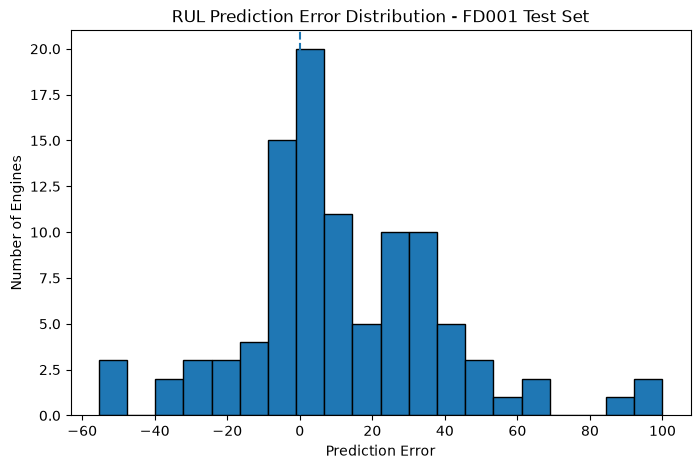

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(
    evaluation["error"],
    bins=20,
    edgecolor="black"
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error")
plt.ylabel("Number of Engines")
plt.title("RUL Prediction Error Distribution - FD001 Test Set")

plt.show()

## Final Evaluation Conclusion

The trained Random Forest regression model was evaluated on the official C-MAPSS FD001 test set.

The final observed cycle of each of the 100 test engines was used to generate one final RUL prediction per engine.

The predictions were compared with the corresponding ground-truth RUL values from `RUL_FD001.txt`.

Model performance was evaluated using MAE, RMSE, and R².

The Actual vs Predicted RUL visualization shows the relationship between predicted and actual RUL values, while the error distribution shows the
overall prediction error behavior.

This evaluation represents the performance of the trained RUL model on previously unseen test engines.